In [1]:
import os
import random
import numpy as np
import tensorflow as tf

# Set seeds
seed = 10
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

2025-05-25 19:44:13.376130: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-25 19:44:13.385765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748216653.396830    8648 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748216653.400217    8648 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748216653.408263    8648 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt            
import keras
from keras.datasets import mnist     
from keras.models import Sequential  

from keras.layers import Dense, Dropout, Activation, BatchNormalization
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
import seaborn as sns

In [3]:
#loading the dataset
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

#printing the shapes of the vectors 
print('X_train: ' + str(X_train.shape))
print('Y_train: ' + str(Y_train.shape))
print('X_test:  '  + str(X_test.shape))
print('Y_test:  '  + str(Y_test.shape))


X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


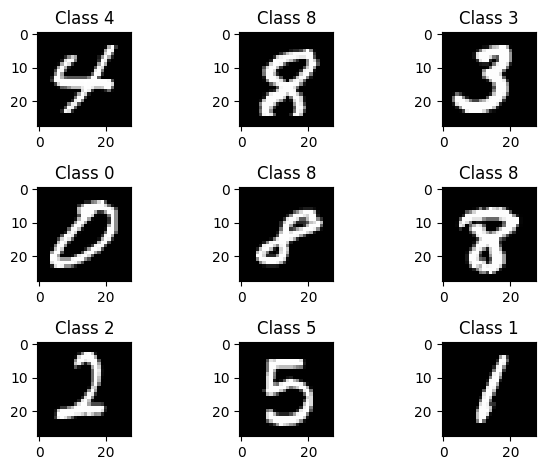

In [4]:
for i in range(9):
    plt.subplot(3,3,i+1)
    num = random.randint(0, len(X_train))
    plt.imshow(X_train[num], cmap='gray', interpolation='none')
    plt.title("Class {}".format(Y_train[num]))
    
plt.tight_layout()

In [5]:
X_train = X_train.reshape(60000, 784) 
X_test = X_test.reshape(10000, 784)   

X_train = X_train.astype('float32')   
X_test = X_test.astype('float32')

X_train /= 255                        
X_test /= 255

print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (60000, 784)
Testing matrix shape (10000, 784)


In [6]:
no_classes = 10

Y_train = to_categorical(Y_train, no_classes)
Y_test = to_categorical(Y_test, no_classes)

In [20]:
model = Sequential()
# Hidden layer 1
model.add(Dense(512, input_shape=(784,)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.4))
# Hidden layer 2
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.4))
# Hidden layer 3
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.4))
# Hidden layer 4
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.4))
# Hidden layer 5
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.4))
# Output layer
model.add(Dense(10))
model.add(Activation('softmax'))
model.summary()

/home/sraja/miniconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,465,866 (5.59 MB)

 Trainable params: 1,461,770 (5.58 MB)

 Non-trainable params: 4,096 (16.00 KB)

In [10]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('model-nn.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
ss=1e-3
batchSize = 512
optimizer=keras.optimizers.Adam(learning_rate=ss)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [ ]:
history = model.fit(X_train, Y_train, batch_size=batchSize, 
                    epochs=100, verbose=1, validation_split=0.2, 
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100


I0000 00:00:1748216659.238896    8784 service.cc:152] XLA service 0x7f88d0015240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748216659.238930    8784 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 SUPER, Compute Capability 8.9
2025-05-25 19:44:19.275616: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748216659.499361    8784 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-05-25 19:44:20.218496: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3252', 556 bytes spill stores, 556 bytes spill loads



87/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5519 - loss: 1.3679

I0000 00:00:1748216661.807122    8784 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-05-25 19:44:22.673703: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3252', 144 bytes spill stores, 144 bytes spill loads

2025-05-25 19:44:24.323041: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3252', 772 bytes spill stores, 772 bytes spill loads

2025-05-25 19:44:24.421725: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3252', 144 bytes spill stores, 144 bytes spill loads



94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5668 - loss: 1.3234

2025-05-25 19:44:26.154008: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_155', 76 bytes spill stores, 76 bytes spill loads

2025-05-25 19:44:26.156911: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_115', 120 bytes spill stores, 120 bytes spill loads

2025-05-25 19:44:26.290580: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_115', 468 bytes spill stores, 468 bytes spill loads

2025-05-25 19:44:26.299731: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_115', 68 bytes spill stores, 68 bytes spill loads

2025-05-25 19:44:26.331640: I external/l

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.5688 - loss: 1.3175 - val_accuracy: 0.9323 - val_loss: 0.2397
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9088 - loss: 0.3000 - val_accuracy: 0.9556 - val_loss: 0.1475
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9340 - loss: 0.2182 - val_accuracy: 0.9633 - val_loss: 0.1226
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9455 - loss: 0.1802 - val_accuracy: 0.9688 - val_loss: 0.1123
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9559 - loss: 0.1513 - val_accuracy: 0.9704 - val_loss: 0.1088
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9589 - loss: 0.1366 - val_accuracy: 0.9734 - val_loss: 0.0982
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9643 - loss: 0.1181 - val_accuracy: 0.9734 - val_loss: 0.0971
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9688 - loss: 0.1050 - val_accuracy: 0.9758 - val_loss: 0

In [12]:
score = model.evaluate(X_test, Y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

2025-05-25 19:44:39.719709: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_115', 188 bytes spill stores, 188 bytes spill loads

2025-05-25 19:44:39.882589: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_155', 4 bytes spill stores, 4 bytes spill loads

2025-05-25 19:44:39.952057: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_155', 92 bytes spill stores, 92 bytes spill loads

2025-05-25 19:44:39.978699: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_155', 76 bytes spill stores, 76 bytes spill loads



283/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9779 - loss: 0.0847

2025-05-25 19:44:41.398536: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_115', 104 bytes spill stores, 104 bytes spill loads

2025-05-25 19:44:41.412128: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_115', 4 bytes spill stores, 4 bytes spill loads

2025-05-25 19:44:41.612136: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_155', 76 bytes spill stores, 76 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9784 - loss: 0.0830
Test loss: 0.06967883557081223
Test accuracy: 0.9825999736785889


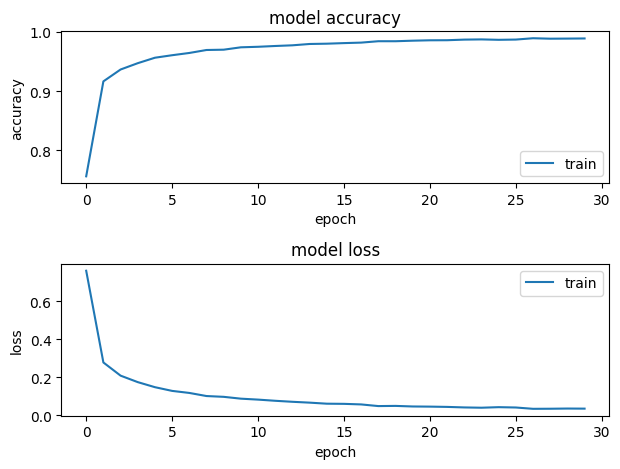

In [13]:
fig = plt.figure()
plt.subplot(2,1,1)
plt.plot(history.history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='lower right')

plt.subplot(2,1,2)
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')

plt.tight_layout()

In [14]:
# Predict labels on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # pick the highest probability with "np.argmax()", and turn it into an index uing "axis=1"

# print vector of probabilities
print(f"What Softmax predicted: {y_pred}")

# print predicted number
print(f"What Softmax actually means: {y_pred_classes}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
What Softmax predicted: [[8.5312704e-14 3.2021330e-10 7.9525391e-09 ... 1.0000000e+00
  1.5450302e-11 5.7115834e-08]
 [2.6456410e-09 2.7289973e-06 9.9999666e-01 ... 1.2147471e-07
  2.4393124e-08 4.4499439e-12]
 [2.7233820e-09 9.9999845e-01 4.2577145e-08 ... 7.6822198e-07
  5.3170066e-07 4.2424176e-08]
 ...
 [1.0022877e-11 1.9333728e-10 1.4582712e-09 ... 4.7229345e-09
  2.3936035e-09 1.5237251e-07]
 [8.6591334e-10 5.0815269e-10 1.7539696e-10 ... 5.0718246e-10
  9.1117380e-07 8.1598364e-09]
 [7.0922055e-14 2.6577816e-18 1.0562589e-15 ... 4.9836588e-20
  3.0259077e-13 2.5306844e-15]]
What Softmax actually means: [7 2 1 ... 4 5 6]


In [15]:
# choose a random sample from all the test data
random_num = np.random.choice(len(X_test))
X_sample = X_test[random_num]

# save true label of this sample in a variable
y_true = np.argmax(Y_test, axis=1)
y_sample_true = y_true[random_num]

# save a predicted label of this sample in a variable
y_sample_pred_class = y_pred_classes[random_num]

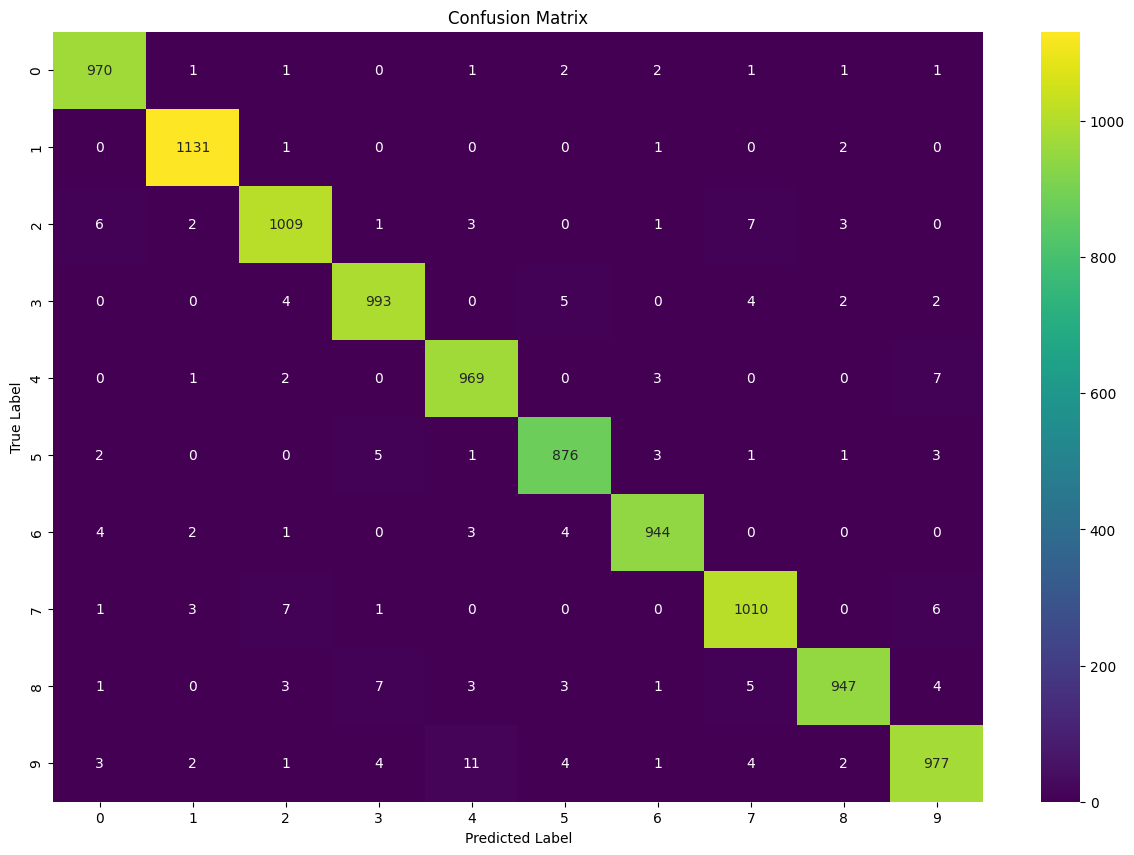

In [16]:
# generate a confusion matrix
confusion_mtx = confusion_matrix(y_true, y_pred_classes)

# visualize confusion matrix with matplotlib and seaborn
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(confusion_mtx, annot=True, fmt="d", ax=ax, cmap="viridis")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix");